## Load RoBERTa Model and Tokenizer and Datasets

In [ ]:
# Install necessary libraries
!pip install transformers datasets
!pip install -q --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.0 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import gc

In [ ]:
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, AutoModelForSequenceClassification
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, TaskType

# Load pre-trained RoBERTa model and tokenizer
model_name = 'roberta-base'
tokenizer = RobertaTokenizerFast.from_pretrained(model_name)
model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2)

print(f"Loaded RoBERTa model: {model_name}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded RoBERTa model: roberta-base


### Load SST-2 Dataset and QNLI Dataset + Tokenize

In [ ]:
# Load SST-2 dataset
sst2_dataset = load_dataset('glue', 'sst2')
print("SST-2 dataset loaded successfully.")
display(sst2_dataset)

# Load QNLI dataset
qnli_dataset = load_dataset('glue', 'qnli')
print("QNLI dataset loaded successfully.")
display(qnli_dataset)

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

Generating train split:   0%|          | 0/104743 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5463 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5463 [00:00<?, ? examples/s]

QNLI dataset loaded successfully.


DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})

In [ ]:
def tokenize_sst2(example):
    return tokenizer(example['sentence'], truncation=True, padding='max_length', max_length=128)

def tokenize_qnli(example):
    return tokenizer(example['question'], example['sentence'], truncation=True, padding='max_length', max_length=128)

sst2_dataset = sst2_dataset.map(tokenize_sst2, batched=True)
sst2_dataset = sst2_dataset.rename_column("label", "labels")
sst2_dataset = sst2_dataset.remove_columns(["sentence", "idx"])

qnli_dataset = qnli_dataset.map(tokenize_qnli, batched=True)
qnli_dataset = qnli_dataset.rename_column("label", "labels")
qnli_dataset = qnli_dataset.remove_columns(["question", "sentence", "idx"])

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

Map:   0%|          | 0/104743 [00:00<?, ? examples/s]

Map:   0%|          | 0/5463 [00:00<?, ? examples/s]

Map:   0%|          | 0/5463 [00:00<?, ? examples/s]

#### LoRA
Let $W_0$ be the pre-trained weight matrix, then the low-rank update rule is $W_0' = W_0' + δW = W_0' + BA$

Modified forward pass: $h = W_0x + BAx$

Initialization: B is 0, A is random Gaussian distribution

Chosen model: RoBERTa

In [ ]:


import importlib, peft
importlib.reload(peft)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16, # The paper suggests setting alpha = 2 * r
    target_modules=["query", "value"], # Paper's recommendation (Section 7.1)
    lora_dropout=0.1
)

lora_model = get_peft_model(model, lora_config)
lora_model.print_trainable_parameters()



trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


In [ ]:
from sklearn.metrics import accuracy_score
import importlib, peft
importlib.reload(peft)

def run_experiment(base_result_list, lora_result_list):
  """
  Create a new LoRA model with some parameters and run the experiment.
  """

  rank_lst = [1, 2, 4, 8, 16, 32]
  all_log_histories = [] # List to store log histories for each rank

  for rank in rank_lst:

    model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2)

    lora_config = LoraConfig(
      task_type=TaskType.SEQ_CLS,
      r=rank,
      lora_alpha=rank * 2, # Setting alpha = 2 * r as per paper suggestion
      target_modules=["query", "value"], # Paper's recommendation (Section 7.1)
      lora_dropout=0.1)

    lora_model = get_peft_model(model, lora_config)
    training_args = TrainingArguments(
      output_dir=f"./rank_{rank}_output",
      learning_rate=2e-4,          # Specific LoRA LR from Paper Appendix D - REDUCED LR
      per_device_train_batch_size=32,
      num_train_epochs=5,         # GLUE tasks usually require more than 1 epoch - INCREASED EPOCHS
      fp16 = True,
      weight_decay=0.01,
      save_strategy="epoch",
      logging_strategy="epoch",
      logging_steps= 100
      #fp16=True, # Enable mixed precision training
    )

    trainer = Trainer(
        model=lora_model,
        args=training_args,
        train_dataset=qnli_dataset['train']
        # compute_metrics=compute_metrics
    )

    trainer.train()

    all_log_histories.append(trainer.state.log_history) # Store the full log history

    print(f"Total Training Time: {trainer.state.log_history[-1]['train_runtime']/60:.2f} minutes")
    # Merges Ba into W_original so the model runs at full speed
    def compute_metrics(eval_pred):
      logits, labels = eval_pred
      predictions = np.argmax(logits, axis=-1)
      return {"accuracy": accuracy_score(labels, predictions)}


    print(f"Evaluating Performance for Rank: {rank}")
    # Evaluation for Baseline RoBERTa
    print("=== Evaluating Baseline RoBERTa ===")
    # Reload the base model to ensure it's untainted for baseline evaluation
    untrained_base_model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2)
    base_evaluation_trainer = Trainer(
        model=untrained_base_model, # Use the freshly loaded original base model
        args=training_args, # Reuse training args, primarily for eval_batch_size and output_dir
        eval_dataset=qnli_dataset['validation'],
        compute_metrics=compute_metrics,
    )
    base_results = base_evaluation_trainer.evaluate()
    print(f"Baseline RoBERTa Evaluation Results: {base_results}")

    # Evaluation for LoRA Fine-Tuned RoBERTa
    print("\n=== Evaluating LoRA Fine-Tuned RoBERTa ===")
    # The lora_model was trained and then merged into merged_model. Use merged_model for LoRA evaluation.
    lora_evaluation_trainer = Trainer(
        model=lora_model, # Use the LoRA fine-tuned and merged model
        args=training_args, # Reuse training args, primarily for eval_batch_size and output_dir
        eval_dataset=qnli_dataset['validation'],
        compute_metrics=compute_metrics,
    )
    lora_results = lora_evaluation_trainer.evaluate()
    print(f"LoRA Fine-Tuned RoBERTa Evaluation Results: {lora_results}")
    base_result_list.append(base_results)
    lora_result_list.append(lora_results)
    del model, lora_model, lora_config, trainer
    del untrained_base_model, base_evaluation_trainer, lora_evaluation_trainer
    torch.cuda.empty_cache()
    gc.collect()
    print("-" * 30)
  return rank_lst, base_result_list, lora_result_list, all_log_histories

_, base, lora, log_histories = run_experiment([], [])
print("DONE")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
3274,0.610731
6548,0.578751
9822,0.570805
13096,0.565436
16370,0.561959


Total Training Time: 14.98 minutes
Evaluating Performance for Rank: 1
=== Evaluating Baseline RoBERTa ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Total Training Time: 15.41 minutes
Evaluating Performance for Rank: 32
=== Evaluating Baseline RoBERTa ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Baseline RoBERTa Evaluation Results: {'eval_loss': 0.696878969669342, 'eval_model_preparation_time': 0.0029, 'eval_accuracy': 0.5053999633900788, 'eval_runtime': 10.7686, 'eval_samples_per_second': 507.307, 'eval_steps_per_second': 63.425}

=== Evaluating LoRA Fine-Tuned RoBERTa ===


LoRA Fine-Tuned RoBERTa Evaluation Results: {'eval_loss': 0.5273237228393555, 'eval_model_preparation_time': 0.0049, 'eval_accuracy': 0.7391543108182317, 'eval_runtime': 15.1958, 'eval_samples_per_second': 359.508, 'eval_steps_per_second': 44.947}
------------------------------
DONE


In [ ]:
rank_lst = [1,2,4,8,16,32]
for i in range(len(base)):
  print(f"Rank: {rank_lst[i]}, Base accuracy: {base[i]["eval_accuracy"]}, LoRA accuracy: {lora[i]['eval_accuracy']}")
#
  #print(lora[i]["eval_accuracy"])

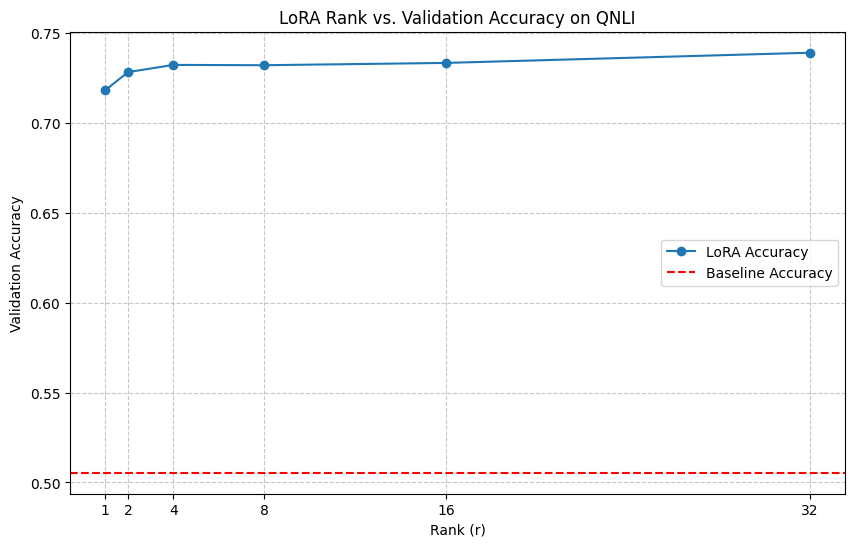

In [ ]:
import matplotlib.pyplot as plt

#baseline_eval = [0.5091743119266054]
#LoRA_eval = [0.6731651376146789, 0.698394495412844, 0.7121559633027523, 0.7236238532110092, 0.7282110091743119 ,0.7247706422018348]

baseline_eval = [base[i]["eval_accuracy"] for i in range(len(base))]
LoRA_eval = [lora[i]["eval_accuracy"] for i in range(len(lora))]
rank = [1,2,4,8,16,32]

plt.figure(figsize=(10, 6)) # Make the plot larger
plt.plot(rank, LoRA_eval, marker='o', linestyle='-', label='LoRA Accuracy')
plt.axhline(y=baseline_eval[0], color='r', linestyle='--', label='Baseline Accuracy') # Plot baseline as a horizontal dashed line

plt.xlabel('Rank (r)')
plt.xticks(rank)
plt.ylabel('Validation Accuracy')
plt.title('LoRA Rank vs. Validation Accuracy on QNLI')
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for better readability
plt.legend()
plt.show()

In [ ]:
runtime.unassign()

[{'eval_loss': 0.7014738917350769, 'eval_model_preparation_time': 0.0033, 'eval_accuracy': 0.5053999633900788, 'eval_runtime': 12.7573, 'eval_samples_per_second': 428.227, 'eval_steps_per_second': 53.538}, {'eval_loss': 0.7014738917350769, 'eval_model_preparation_time': 0.0051, 'eval_accuracy': 0.5053999633900788, 'eval_runtime': 12.699, 'eval_samples_per_second': 430.192, 'eval_steps_per_second': 53.784}, {'eval_loss': 0.7014738917350769, 'eval_model_preparation_time': 0.0052, 'eval_accuracy': 0.5053999633900788, 'eval_runtime': 12.9201, 'eval_samples_per_second': 422.831, 'eval_steps_per_second': 52.864}, {'eval_loss': 0.7014738917350769, 'eval_model_preparation_time': 0.0047, 'eval_accuracy': 0.5053999633900788, 'eval_runtime': 12.9249, 'eval_samples_per_second': 422.672, 'eval_steps_per_second': 52.844}]
[{'eval_loss': 0.5351657271385193, 'eval_model_preparation_time': 0.0052, 'eval_accuracy': 0.7321984257733846, 'eval_runtime': 15.0833, 'eval_samples_per_second': 362.189, 'eval_steps_per_second': 45.282}, {'eval_loss': 0.5370843410491943, 'eval_model_preparation_time': 0.0053, 'eval_accuracy': 0.7259747391543108, 'eval_runtime': 14.9664, 'eval_samples_per_second': 365.017, 'eval_steps_per_second': 45.635}, {'eval_loss': 0.529844343662262, 'eval_model_preparation_time': 0.0057, 'eval_accuracy': 0.733479773018488, 'eval_runtime': 15.6632, 'eval_samples_per_second': 348.78, 'eval_steps_per_second': 43.606}, {'eval_loss': 0.5354149341583252, 'eval_model_preparation_time': 0.0049, 'eval_accuracy': 0.7356763682958082, 'eval_runtime': 15.3821, 'eval_samples_per_second': 355.154, 'eval_steps_per_second': 44.402}]

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracies from the lists of dictionaries
baseline_eval_accuracies = [result['eval_accuracy'] for result in base]
lora_eval_accuracies = [result['eval_accuracy'] for result in lora]
rank_lst = [1,2,4,8,16,32]

plt.figure(figsize=(10, 6)) # Make the plot larger
plt.plot(rank_lst, lora_eval_accuracies, marker='o', linestyle='-', label='LoRA Accuracy')

# Since baseline accuracy appears constant, we can plot it as a single horizontal line
# using the first baseline accuracy value, assuming all are the same.
if baseline_eval_accuracies:
    plt.axhline(y=baseline_eval_accuracies[0], color='r', linestyle='--', label='Baseline Accuracy')

plt.xlabel('Rank (r)')
plt.xticks(rank_lst)
plt.ylabel('Validation Accuracy')
plt.title('LoRA Rank vs. Validation Accuracy on QNLI') # Changed title to reflect QNLI dataset
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for better readability
plt.legend()
plt.show()

### Re-running Experiment for Rank 16 to check consistency

To confirm if the low accuracy for `rank=16` is a consistent issue or a random fluctuation, we will re-run the experiment for this specific rank multiple times.

In [ ]:
num_reruns = 5 # Number of times to re-run the experiment for rank 16
rank_16_base_accuracies = []
rank_16_lora_accuracies = []

print(f"Re-running experiment for rank 16, {num_reruns} times...")

for i in range(num_reruns):
    print(f"\n--- Rerun {i+1}/{num_reruns} for Rank 16 ---")

    model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2)

    rank = 16
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=rank,
        lora_alpha=rank * 2,
        target_modules=["query", "value"],
        lora_dropout=0.1
    )

    lora_model = get_peft_model(model, lora_config)
    training_args = TrainingArguments(
        output_dir=f"./rank_{rank}_output_rerun_{i+1}",
        learning_rate=5e-4,
        per_device_train_batch_size=32,
        num_train_epochs=3,
        fp16 = True,
        weight_decay=0.01,
        save_strategy="epoch",
        logging_strategy="epoch",
        logging_steps= 100
    )

    trainer = Trainer(
        model=lora_model,
        args=training_args,
        train_dataset=qnli_dataset['train']
    )

    trainer.train()

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return {"accuracy": accuracy_score(labels, predictions)}

    # Evaluate Baseline
    untrained_base_model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2)
    base_evaluation_trainer = Trainer(
        model=untrained_base_model,
        args=training_args,
        eval_dataset=qnli_dataset['validation'],
        compute_metrics=compute_metrics,
    )
    base_results = base_evaluation_trainer.evaluate()
    rank_16_base_accuracies.append(base_results['eval_accuracy'])
    print(f"Baseline Accuracy (Rerun {i+1}): {base_results['eval_accuracy']}")

    # Evaluate LoRA
    lora_evaluation_trainer = Trainer(
        model=lora_model,
        args=training_args,
        eval_dataset=qnli_dataset['validation'],
        compute_metrics=compute_metrics,
    )
    lora_results = lora_evaluation_trainer.evaluate()
    rank_16_lora_accuracies.append(lora_results['eval_accuracy'])
    print(f"LoRA Accuracy (Rerun {i+1}): {lora_results['eval_accuracy']}")

    # Clean up memory
    del model, lora_model, lora_config, trainer
    del untrained_base_model, base_evaluation_trainer, lora_evaluation_trainer
    torch.cuda.empty_cache()
    gc.collect()

print("\n--- Reruns Complete ---")
print(f"All Rank 16 Base Accuracies: {rank_16_base_accuracies}")
print(f"Average Rank 16 Base Accuracy: {np.mean(rank_16_base_accuracies):.4f}")
print(f"All Rank 16 LoRA Accuracies: {rank_16_lora_accuracies}")
print(f"Average Rank 16 LoRA Accuracy: {np.mean(rank_16_lora_accuracies):.4f}")

### Analyzing Training and Evaluation Metrics from Log Histories

Now that we have the `log_histories` for each rank, let's extract and visualize the training loss, evaluation loss, and evaluation accuracy across epochs. This will help us identify any patterns or anomalies in the learning process for `rank=16` and `rank=32`.

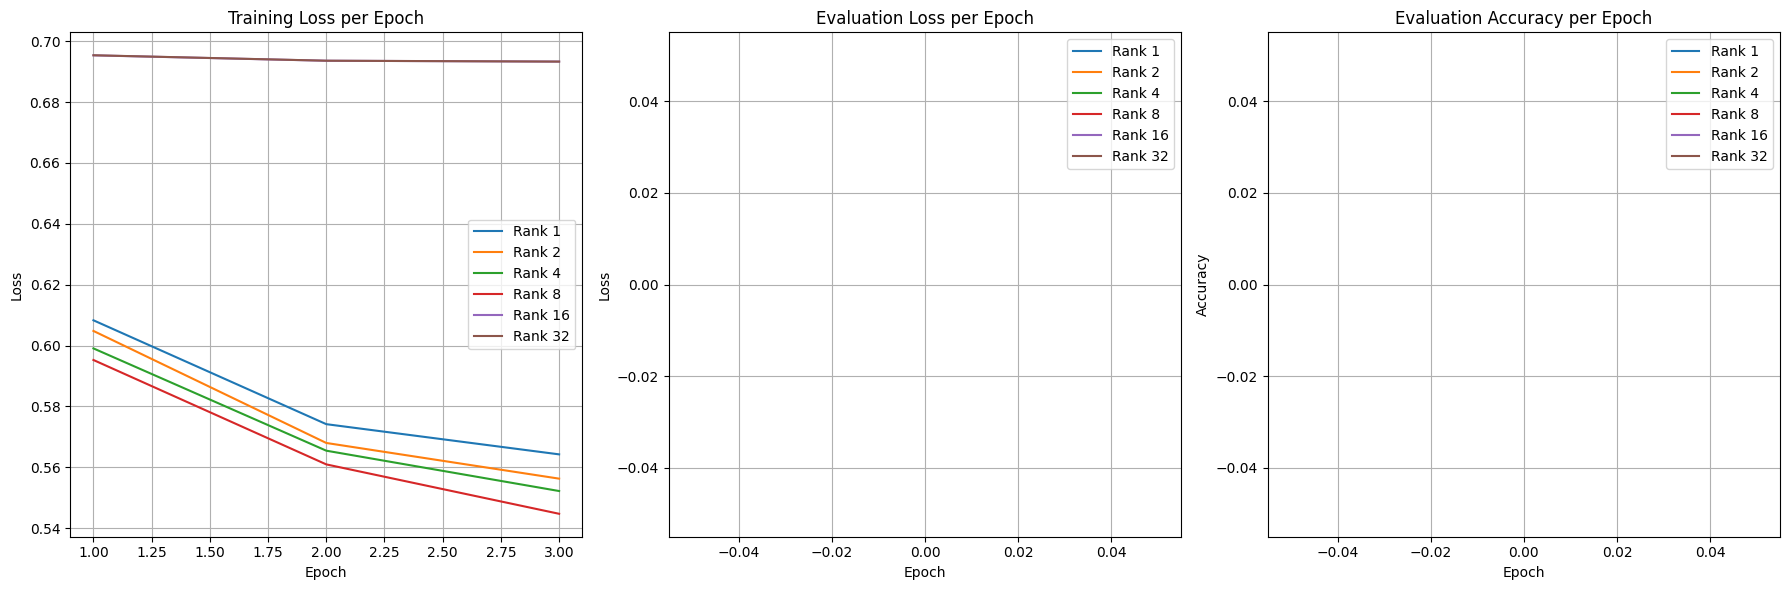

In [ ]:
import matplotlib.pyplot as plt

rank_lst = [1, 2, 4, 8, 16, 32]

plt.figure(figsize=(18, 6))

# Plot Training Loss
plt.subplot(1, 3, 1)
for i, rank in enumerate(rank_lst):
    train_losses = [entry['loss'] for entry in log_histories[i] if 'loss' in entry]
    epochs = [entry['epoch'] for entry in log_histories[i] if 'loss' in entry]
    plt.plot(epochs, train_losses, label=f'Rank {rank}')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Evaluation Loss
plt.subplot(1, 3, 2)
for i, rank in enumerate(rank_lst):
    eval_losses = [entry['eval_loss'] for entry in log_histories[i] if 'eval_loss' in entry]
    epochs = [entry['epoch'] for entry in log_histories[i] if 'eval_loss' in entry]
    plt.plot(epochs, eval_losses, label=f'Rank {rank}')
plt.title('Evaluation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Evaluation Accuracy
plt.subplot(1, 3, 3)
for i, rank in enumerate(rank_lst):
    eval_accuracies = [entry['eval_accuracy'] for entry in log_histories[i] if 'eval_accuracy' in entry]
    epochs = [entry['epoch'] for entry in log_histories[i] if 'eval_accuracy' in entry]
    plt.plot(epochs, eval_accuracies, label=f'Rank {rank}')
plt.title('Evaluation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Results(training loss not reseting for some reason...)

Baseline: 0.5091743119266054
Rank  LoRA
1, | 0.6915137614678899 \
2, | 0.7121559633027523 \
4, | 0.7293577981651376 \
8, | 0.7419724770642202 \
16,| 0.7385321100917431 \
32,| 0.7396788990825688

In [ ]:

print(f"Base list: {base}") # a bit pointless
print(f"Lora list: {lora}")

# very similar, may have to run for 16 and 32

Base: [0.5091743119266054, 0.5091743119266054, 0.5091743119266054, 0.5091743119266054] \
LoRA: [0.6731651376146789, 0.698394495412844, 0.7121559633027523, 0.7236238532110092, 0.7282110091743119 ,0.7247706422018348]


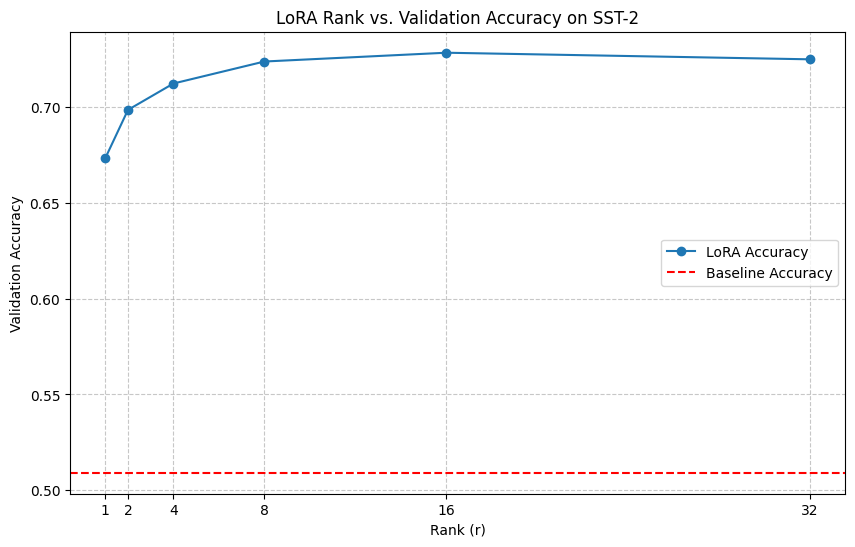

In [ ]:
import matplotlib.pyplot as plt

baseline_eval = [0.5091743119266054]
LoRA_eval = [0.6731651376146789, 0.698394495412844, 0.7121559633027523, 0.7236238532110092, 0.7282110091743119 ,0.7247706422018348]
rank = [1,2,4,8,16,32]

plt.figure(figsize=(10, 6)) # Make the plot larger
plt.plot(rank, LoRA_eval, marker='o', linestyle='-', label='LoRA Accuracy')
plt.axhline(y=baseline_eval[0], color='r', linestyle='--', label='Baseline Accuracy') # Plot baseline as a horizontal dashed line

plt.xlabel('Rank (r)')
plt.xticks(rank)
plt.ylabel('Validation Accuracy')
plt.title('LoRA Rank vs. Validation Accuracy on SST-2')
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for better readability
plt.legend()
plt.show()

In [ ]:
# Clean up some memory
# del base_evaluation_trainer
# del lora_evaluation_trainer
torch.cuda.empty_cache()
gc.collect()

In [ ]:
output_dir = "./lora_roberta_saved"
lora_model.save_pretrained(output_dir)
print(f"LoRA model saved to {output_dir}")

To load the model later, you would first load the base model, then use `PeftModel.from_pretrained` to load the LoRA weights on top of it. For example:

```python
from peft import PeftModel, PeftConfig
from transformers import RobertaForSequenceClassification

# Load the configuration
config = PeftConfig.from_pretrained(output_dir)

# Load the base model
base_model = RobertaForSequenceClassification.from_pretrained(config.base_model_name_or_path)

# Load the LoRA adapter onto the base model
loaded_lora_model = PeftModel.from_pretrained(base_model, output_dir)

print("LoRA model loaded successfully!")
```